# 实验数据加载与清洗示例

演示 `src.exp_loader` 与 `src.data_cleaning` 在**只有一份测试设备导出 CSV**情况下的典型用法：
- 从文件名自动解析温度与倍率（`parse_condition_from_filename`）
- 中/英文列名自动对齐（`load_cycling_csv`）
- 整个文件夹批量加载（`load_cycling_folder`）
- 二维曲线去噪/去重/排序（`clean_xy_curve`）

为了让 notebook 不依赖真实实验文件，下面会在临时目录里造几份最小 fixture CSV。

In [1]:
# --- BatteryProject 路径自动定位 (无论从 root 还是 examples/ 启动 notebook 都能工作) ---
import sys
from pathlib import Path

_HERE = Path.cwd().resolve()
for _cand in (_HERE, *_HERE.parents):
    if (_cand / "src" / "easy_imports.py").exists() and (_cand / "pyproject.toml").exists():
        _ROOT = _cand
        break
else:
    raise RuntimeError(f"Cannot locate BatteryProject root from {_HERE}")
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))
print("BatteryProject root:", _ROOT)

BatteryProject root: D:\Users\hez\Desktop\hithium\BatteryProject


In [2]:
from src.easy_imports import *
from src.exp_loader import load_cycling_csv, load_cycling_folder, parse_condition_from_filename
from src.data_cleaning import clean_xy_curve, load_curve_file

import numpy as np
import pandas as pd
import tempfile
from pathlib import Path

## 1. 文件名解析

`parse_condition_from_filename` 是个纯字符串函数，能识别常见命名（℃/°C、P/C 倍率）。

In [3]:
for name in [
    "25℃-0.5P.csv",
    "45°C_1P.csv",
    "0.25P_-10C.csv",
    "BatteryA_25C_0.5C_200cycles.csv",
    "some-other-file.csv",  # 解析不到时回退到 stem
]:
    print(f"{name:40s}  →  {parse_condition_from_filename(name)}")

25℃-0.5P.csv                              →  {'temperature': '25°C', 'rate': '0.5P', 'label': '25°C 0.5P'}
45°C_1P.csv                               →  {'temperature': '45°C', 'rate': '1P', 'label': '45°C 1P'}
0.25P_-10C.csv                            →  {'temperature': '-10°C', 'rate': '10P', 'label': '-10°C 10P'}
BatteryA_25C_0.5C_200cycles.csv           →  {'temperature': '25°C', 'label': '25°C'}
some-other-file.csv                       →  {'label': 'some-other-file'}


## 2. 造一份最小 fixture CSV

测试设备导出的 CSV 通常包含「循环圈数 / 放电容量 / 充电容量 / 容量保持率 / 能量效率」等列。
下面在临时目录里造一份典型格式。

In [4]:
tmp = Path(tempfile.mkdtemp(prefix="exp_demo_"))
print("临时目录:", tmp)

rng = np.random.default_rng(42)
cycle = np.arange(1, 51)
discharge_cap = 1175 * (1.0 - 1.2e-4 * cycle) + rng.normal(0, 0.5, cycle.size)
charge_cap = discharge_cap / 0.995
retention_pct = (discharge_cap / discharge_cap[0]) * 100  # 百分制
efficiency = discharge_cap / charge_cap

df = pd.DataFrame({
    "循环圈数": cycle,
    "放电容量(Ah)": discharge_cap,
    "充电容量(Ah)": charge_cap,
    "容量保持率": retention_pct,
    "能量效率": efficiency,
})

csv_a = tmp / "25℃-0.5P.csv"
csv_b = tmp / "45℃-0.5P.csv"
df.to_csv(csv_a, index=False, encoding="utf-8-sig")

# 第二份（45°C，更快衰减）
df2 = df.copy()
df2["放电容量(Ah)"] = 1175 * (1.0 - 4e-4 * cycle) + rng.normal(0, 0.5, cycle.size)
df2["容量保持率"] = df2["放电容量(Ah)"] / df2["放电容量(Ah)"].iloc[0] * 100
df2.to_csv(csv_b, index=False, encoding="utf-8-sig")

df.head()

临时目录: C:\Users\hez\AppData\Local\Temp\exp_demo_g1xt8kxq


,循环圈数,放电容量(Ah),充电容量(Ah),容量保持率,能量效率
0,1,1175.011359,1180.915938,100.000000,0.995
1,2,1174.198008,1180.098500,99.930779,0.995
2,3,1174.952226,1180.856508,99.994967,0.995
3,4,1174.906282,1180.810334,99.991057,0.995
4,5,1173.319482,1179.215560,99.856012,0.995


## 3. 单文件加载 `load_cycling_csv`

返回值是统一格式 dict：键固定为 `label / cycle / discharge_capacity / charge_capacity /
retention / efficiency / max_force / min_force / discharge_energy / charge_energy / temperature`。

保持率会自动**判断百分制并归一化到 0–1 小数**（mean > 2 视为百分制）。

In [5]:
data = load_cycling_csv(csv_a)
print("label   :", data["label"])
print("cycle   :", data["cycle"][:5], "...")
print("capacity:", data["discharge_capacity"][:3].round(2), "...")
print("retention:", data["retention"][:5].round(4), "... (自动从百分制归一化)")
print("keys    :", list(data.keys()))

label   : 25°C 0.5P
cycle   : [1. 2. 3. 4. 5.] ...
capacity: [1175.01 1174.2  1174.95] ...
retention: [1.     0.9993 0.9999 0.9999 0.9986] ... (自动从百分制归一化)
keys    : ['label', 'cycle', 'discharge_capacity', 'charge_capacity', 'retention', 'efficiency', 'max_force', 'min_force', 'discharge_energy', 'charge_energy', 'temperature']


## 4. 批量加载 `load_cycling_folder`

把上面两份 CSV 一次性读出，按 label 排序，返回 `list[dict]`。
这是 `src.compare.compare_all(exp_folder=...)` 内部使用的入口。

In [6]:
exp_list = load_cycling_folder(tmp)
for d in exp_list:
    last_ret = d["retention"][-1] if d["retention"].size else float("nan")
    print(f"{d['label']:15s}  cycle 数={d['cycle'].size:3d}  末圈保持率={last_ret:.4f}")

25°C 0.5P        cycle 数= 50  末圈保持率=0.9940
45°C 0.5P        cycle 数= 50  末圈保持率=0.9799


## 5. 二维曲线清洗 `clean_xy_curve`

对任意 `(x, y)` 序列做：去 NaN/字符串 → 去重 → 按 x 排序 → 可选 Savitzky-Golay 平滑。
适用于电压曲线、力曲线等含噪声的实验数据。

In [7]:
# 构造一段带噪声 + 乱序 + 重复 x 的 OCV 曲线
x_raw = np.array([0.1, 0.3, 0.2, 0.3, 0.5, 0.4, 0.4, np.nan, 0.6])
y_raw = np.array([3.2, 3.25, 3.22, 3.26, 3.30, 3.27, 3.28, 9.99, 3.32])

x_clean, y_clean = clean_xy_curve(x_raw, y_raw)
print("原始:", list(zip(x_raw.tolist(), y_raw.tolist())))
print("清洗:", list(zip(x_clean.tolist(), y_clean.tolist())))

原始: [(0.1, 3.2), (0.3, 3.25), (0.2, 3.22), (0.3, 3.26), (0.5, 3.3), (0.4, 3.27), (0.4, 3.28), (nan, 9.99), (0.6, 3.32)]
清洗: [(0.1, 3.2), (0.2, 3.22), (0.3, 3.26), (0.4, 3.28), (0.5, 3.3), (0.6, 3.32)]


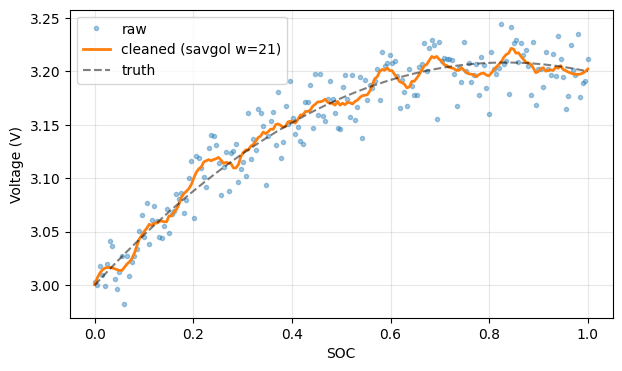

In [8]:
# 真实场景：带噪声电压曲线 + 平滑
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 200)
y_true = 3.0 + 0.5 * x - 0.3 * x**2
y_noisy = y_true + np.random.default_rng(0).normal(0, 0.02, x.size)

x_s, y_s = clean_xy_curve(x, y_noisy, smooth_window=21, smooth_polyorder=3)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, y_noisy, ".", alpha=0.4, label="raw")
ax.plot(x_s, y_s, "-", lw=2, label="cleaned (savgol w=21)")
ax.plot(x, y_true, "--", color="k", alpha=0.5, label="truth")
ax.set_xlabel("SOC"); ax.set_ylabel("Voltage (V)"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 6. 从单文件加载并清洗 `load_curve_file`

对外部 OCV/OCP/dat 等两列文件，一步读 + 清洗。

In [9]:
# 造一份两列 dat 文件
ocp_path = tmp / "LFP_ocp.dat"
with open(ocp_path, "w", encoding="utf-8") as f:
    for xi, yi in zip(x, y_noisy):
        f.write(f"{xi:.6f} {yi:.6f}\n")

x_loaded, y_loaded = load_curve_file(ocp_path, smooth_window=21)
print("加载后样本:", x_loaded.size, "点；前 5 个 y:", y_loaded[:5].round(4))

加载后样本: 200 点；前 5 个 y: [3.0132 3.0116 3.0104 3.0095 3.009 ]


## 收尾：清理临时目录

In [10]:
import shutil
shutil.rmtree(tmp)
print("已清理:", tmp)

已清理: C:\Users\hez\AppData\Local\Temp\exp_demo_g1xt8kxq
